In [5]:
# Skin Cancer Temporal Change Detection System
# Using Vision Transformer (ViT) to detect clinically concerning changes in lesions

import kagglehub
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import json
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# Set device and optimize for fastest GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    # Use the fastest GPU if multiple GPUs available
    if torch.cuda.device_count() > 1:
        # Get GPU with most memory (usually fastest)
        gpu_memory = [torch.cuda.get_device_properties(i).total_memory for i in range(torch.cuda.device_count())]
        best_gpu = np.argmax(gpu_memory)
        device = torch.device(f'cuda:{best_gpu}')
        print(f"Multiple GPUs detected. Using GPU {best_gpu} ({torch.cuda.get_device_name(best_gpu)})")
    else:
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    
    # Enable optimizations
    torch.backends.cudnn.benchmark = True  # Faster convolutions
    torch.backends.cudnn.deterministic = False  # Faster but non-deterministic
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    device = torch.device('cpu')
    print("No GPU detected. Using CPU (will be much slower)")

print(f"PyTorch Version: {torch.__version__}")
print(f"Final device: {device}")

# Download ISIC-2019 dataset
path = kagglehub.dataset_download("agsam23/isic-2019-challenge")
print(f"Dataset downloaded to: {path}")

Using GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.17 GB
CUDA Version: 12.6
PyTorch Version: 2.9.0+cu126
Final device: cuda


100%|██████████| 12.7G/12.7G [05:26<00:00, 41.7MB/s]  

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1


## Section 1: Data Loading and Preprocessing

Load and preprocess the ISIC-2019 dataset. We'll parse metadata, resize images to 224x224, normalize, and create train/validation/test splits.

In [6]:
# Explore dataset structure
dataset_path = Path(path)
print(f"Dataset root: {dataset_path}")
print("\nDirectory structure:")
for item in sorted(dataset_path.iterdir())[:10]:
    print(f"  {item.name}")

# Find images and metadata
image_dirs = []
metadata_files = []
for item in dataset_path.rglob("*"):
    if item.is_dir() and any(x in item.name.lower() for x in ['image', 'train', 'test', 'data']):
        image_dirs.append(item)
    elif item.is_file() and any(x in item.name.lower() for x in ['csv', 'json', 'meta']):
        metadata_files.append(item)

print(f"\nFound {len(image_dirs)} potential image directories")
print(f"Found {len(metadata_files)} potential metadata files")

Dataset root: /root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1

Directory structure:
  ISIC_2019_Test_Input
  ISIC_2019_Test_Metadata.csv
  ISIC_2019_Training_GroundTruth.csv
  ISIC_2019_Training_Input
  ISIC_2019_Training_Metadata.csv

Found 4 potential image directories
Found 3 potential metadata files


In [5]:
# Find all image files
image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
image_files = []
for ext in image_extensions:
    image_files.extend(list(dataset_path.rglob(f"*{ext}")))

print(f"Found {len(image_files)} image files")
if len(image_files) > 0:
    print(f"Sample image: {image_files[0]}")
    print(f"Sample image parent: {image_files[0].parent}")

Found 33569 image files
Sample image: /root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0027975.jpg
Sample image parent: /root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1/ISIC_2019_Training_Input/ISIC_2019_Training_Input


In [6]:
# Load metadata if available
metadata = None
for meta_file in metadata_files:
    try:
        if meta_file.suffix == '.csv':
            metadata = pd.read_csv(meta_file)
            print(f"Loaded metadata from: {meta_file}")
            print(f"Metadata shape: {metadata.shape}")
            print(f"Columns: {list(metadata.columns)}")
            break
    except Exception as e:
        print(f"Could not load {meta_file}: {e}")

if metadata is not None and len(metadata) > 0:
    print("\nFirst few rows:")
    print(metadata.head())
else:
    print("No metadata found. We'll create a simple dataset from images.")

Loaded metadata from: /root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1/ISIC_2019_Test_Metadata.csv
Metadata shape: (8238, 4)
Columns: ['image', 'age_approx', 'anatom_site_general', 'sex']

First few rows:
          image  age_approx anatom_site_general     sex
0  ISIC_0034321        60.0                 NaN  female
1  ISIC_0034322        70.0      anterior torso    male
2  ISIC_0034323        70.0     lower extremity    male
3  ISIC_0034324        70.0     lower extremity    male
4  ISIC_0034325        30.0     upper extremity  female


In [7]:
# Create a dataset structure
# For ISIC-2019, we'll work with available images and create our own labels for change detection

class SkinLesionDataset(Dataset):
    """Dataset for skin lesion images"""
    def __init__(self, image_paths, labels=None, transform=None, max_samples=None):
        self.image_paths = image_paths[:max_samples] if max_samples else image_paths
        self.labels = labels[:max_samples] if labels and max_samples else labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            
            if self.labels is not None:
                return image, self.labels[idx]
            return image
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a black image as fallback
            if self.transform:
                return self.transform(Image.new('RGB', (224, 224)))
            return Image.new('RGB', (224, 224))

# Image preprocessing transforms
image_size = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                  std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    normalize
])

print("Dataset class and transforms defined")

Dataset class and transforms defined


In [8]:
# Prepare image paths and create splits
# Use a subset for faster development (can increase later)
MAX_SAMPLES = 5000 if len(image_files) > 5000 else len(image_files)
print(f"Using {MAX_SAMPLES} images for development")

# Shuffle and split
np.random.seed(42)
indices = np.random.permutation(len(image_files))[:MAX_SAMPLES]
selected_images = [str(image_files[i]) for i in indices]

# Split into train/val/test (70/15/15)
train_images, temp_images = train_test_split(selected_images, test_size=0.3, random_state=42)
val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)

print(f"Train: {len(train_images)} images")
print(f"Validation: {len(val_images)} images")
print(f"Test: {len(test_images)} images")

Using 5000 images for development
Train: 3500 images
Validation: 750 images
Test: 750 images


## Section 2: Temporal Sequence Simulation

Create synthetic temporal sequences by applying progressive transformations to simulate lesion evolution over time. This simulates how a lesion might change (size, border, color, shape) between baseline and follow-up visits.

In [9]:
# Temporal sequence simulation
# Generate synthetic lesion evolution with clinically realistic transformations

class TemporalLesionSimulator:
    """Simulates temporal changes in skin lesions"""
    
    def __init__(self, image_size=224):
        self.image_size = image_size
    
    def apply_size_growth(self, image, growth_factor=1.0):
        """Simulate lesion size increase"""
        if growth_factor <= 1.0:
            return image
        
        # Convert to numpy
        img_array = np.array(image)
        h, w = img_array.shape[:2]
        
        # Create mask for the lesion (simplified - in real scenario, would segment)
        # For simulation, we'll apply transformation to the whole image
        center = (w // 2, h // 2)
        
        # Scale up
        scale = growth_factor
        M = cv2.getRotationMatrix2D(center, 0, scale)
        new_w, new_h = int(w * scale), int(h * scale)
        
        # Crop back to original size
        img_scaled = cv2.warpAffine(img_array, M, (new_w, new_h))
        if new_w > w or new_h > h:
            start_x = (new_w - w) // 2
            start_y = (new_h - h) // 2
            img_scaled = img_scaled[start_y:start_y+h, start_x:start_x+w]
        else:
            # Pad if smaller
            pad_x = (w - new_w) // 2
            pad_y = (h - new_h) // 2
            img_scaled = cv2.copyMakeBorder(img_scaled, pad_y, h-new_h-pad_y, 
                                          pad_x, w-new_w-pad_x, cv2.BORDER_REPLICATE)
        
        return Image.fromarray(img_scaled)
    
    def apply_border_irregularity(self, image, irregularity=0.0):
        """Simulate border irregularity changes"""
        if irregularity == 0:
            return image
        
        img_array = np.array(image)
        h, w = img_array.shape[:2]
        
        # Apply slight distortion to simulate irregular borders
        noise = np.random.randn(h, w, 2) * irregularity * 10
        map_x = np.float32(np.arange(w).reshape(1, -1) + noise[:, :, 0])
        map_y = np.float32(np.arange(h).reshape(-1, 1) + noise[:, :, 1])
        
        img_distorted = cv2.remap(img_array, map_x, map_y, cv2.INTER_LINEAR)
        return Image.fromarray(img_distorted)
    
    def apply_color_variation(self, image, darken_factor=0.0, color_shift=0.0):
        """Simulate color changes (darkening, multi-color development)"""
        img_array = np.array(image).astype(np.float32)
        
        # Darkening
        if darken_factor > 0:
            img_array = img_array * (1 - darken_factor * 0.3)
        
        # Color shift (simulate multi-color development)
        if color_shift > 0:
            # Add slight color variation
            shift = np.random.randn(3) * color_shift * 20
            img_array[:, :, 0] = np.clip(img_array[:, :, 0] + shift[0], 0, 255)
            img_array[:, :, 1] = np.clip(img_array[:, :, 1] + shift[1], 0, 255)
            img_array[:, :, 2] = np.clip(img_array[:, :, 2] + shift[2], 0, 255)
        
        img_array = np.clip(img_array, 0, 255).astype(np.uint8)
        return Image.fromarray(img_array)
    
    def apply_shape_asymmetry(self, image, asymmetry=0.0):
        """Simulate shape asymmetry changes"""
        if asymmetry == 0:
            return image
        
        img_array = np.array(image)
        h, w = img_array.shape[:2]
        
        # Apply slight affine transformation
        center = (w // 2, h // 2)
        angle = asymmetry * 5  # Small rotation
        scale_x = 1.0 + asymmetry * 0.1  # Slight stretch
        scale_y = 1.0 - asymmetry * 0.05
        
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        M[0, 0] *= scale_x
        M[1, 1] *= scale_y
        
        img_transformed = cv2.warpAffine(img_array, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
        return Image.fromarray(img_transformed)
    
    def generate_followup(self, baseline_image, change_severity='none'):
        """
        Generate a follow-up image with specified change severity
        
        change_severity: 'none', 'minor', 'moderate', 'significant'
        """
        followup = baseline_image.copy()
        
        if change_severity == 'none':
            # No change - just add slight noise
            return followup
        
        elif change_severity == 'minor':
            # Minor changes: slight size increase, minimal border/color changes
            followup = self.apply_size_growth(followup, growth_factor=1.05)
            followup = self.apply_border_irregularity(followup, irregularity=0.02)
            followup = self.apply_color_variation(followup, darken_factor=0.05, color_shift=0.02)
        
        elif change_severity == 'moderate':
            # Moderate changes: noticeable size increase, border irregularity, color changes
            followup = self.apply_size_growth(followup, growth_factor=1.12)
            followup = self.apply_border_irregularity(followup, irregularity=0.05)
            followup = self.apply_color_variation(followup, darken_factor=0.10, color_shift=0.05)
            followup = self.apply_shape_asymmetry(followup, asymmetry=0.03)
        
        elif change_severity == 'significant':
            # Significant changes: substantial size increase, irregular borders, color variation
            followup = self.apply_size_growth(followup, growth_factor=1.20)
            followup = self.apply_border_irregularity(followup, irregularity=0.10)
            followup = self.apply_color_variation(followup, darken_factor=0.15, color_shift=0.10)
            followup = self.apply_shape_asymmetry(followup, asymmetry=0.06)
        
        return followup

simulator = TemporalLesionSimulator(image_size=image_size)
print("Temporal lesion simulator created")

Temporal lesion simulator created


In [10]:
# Create temporal pairs dataset
class TemporalPairDataset(Dataset):
    """Dataset for baseline-followup image pairs with change labels"""
    
    def __init__(self, image_paths, simulator, transform=None, change_distribution=None):
        self.image_paths = image_paths
        self.simulator = simulator
        self.transform = transform
        
        # Distribution of change severities
        # change_distribution: {'none': 0.4, 'minor': 0.3, 'moderate': 0.2, 'significant': 0.1}
        if change_distribution is None:
            change_distribution = {'none': 0.4, 'minor': 0.3, 'moderate': 0.2, 'significant': 0.1}
        self.change_distribution = change_distribution
        
        # Pre-generate change labels for each image
        self.change_labels = []
        self.severity_to_class = {'none': 0, 'minor': 1, 'moderate': 2, 'significant': 3}
        
        np.random.seed(42)
        for _ in range(len(image_paths)):
            # Sample change severity according to distribution
            rand = np.random.random()
            cumsum = 0
            for severity, prob in change_distribution.items():
                cumsum += prob
                if rand <= cumsum:
                    self.change_labels.append(self.severity_to_class[severity])
                    break
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        change_class = self.change_labels[idx]
        
        # Load baseline image
        try:
            baseline = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            baseline = Image.new('RGB', (image_size, image_size))
        
        # Get change severity string
        severity_str = [k for k, v in self.severity_to_class.items() if v == change_class][0]
        
        # Generate follow-up image
        followup = self.simulator.generate_followup(baseline, change_severity=severity_str)
        
        # Apply transforms
        if self.transform:
            baseline = self.transform(baseline)
            followup = self.transform(followup)
        else:
            baseline = transforms.ToTensor()(baseline)
            followup = transforms.ToTensor()(followup)
        
        # Return both images and label
        # Label: 0 = no change, 1 = minor, 2 = moderate, 3 = significant
        # Also create binary label: 0 = no/minor (non-concerning), 1 = moderate/significant (concerning)
        binary_label = 1 if change_class >= 2 else 0
        
        return {
            'baseline': baseline,
            'followup': followup,
            'change_class': change_class,
            'binary_label': binary_label
        }

# Create datasets
# Check if train_images exists (make sure Cell 6 was run first!)
if 'train_images' not in globals() or 'val_images' not in globals() or 'test_images' not in globals():
    raise NameError(
        "train_images, val_images, or test_images not defined. "
        "Please run Cell 6 (the cell that creates train/val/test splits) first!"
    )

train_pair_dataset = TemporalPairDataset(train_images, simulator, transform=train_transform)
val_pair_dataset = TemporalPairDataset(val_images, simulator, transform=val_transform)
test_pair_dataset = TemporalPairDataset(test_images, simulator, transform=val_transform)

print(f"Created temporal pair datasets:")
print(f"  Train: {len(train_pair_dataset)} pairs")
print(f"  Validation: {len(val_pair_dataset)} pairs")
print(f"  Test: {len(test_pair_dataset)} pairs")

# Test a sample
sample = train_pair_dataset[0]
print(f"\nSample pair shape - Baseline: {sample['baseline'].shape}, Followup: {sample['followup'].shape}")
print(f"Change class: {sample['change_class']}, Binary label: {sample['binary_label']}")

Created temporal pair datasets:
  Train: 3500 pairs
  Validation: 750 pairs
  Test: 750 pairs

Sample pair shape - Baseline: torch.Size([3, 224, 224]), Followup: torch.Size([3, 224, 224])
Change class: 0, Binary label: 0


## Section 3: Feature Extraction Pipeline

Extract clinically relevant features for change tracking: shape (area, asymmetry), border (irregularity), and color (variance, distribution) features.

In [11]:
# Feature extraction for skin lesions
class LesionFeatureExtractor:
    """Extract clinically relevant features from skin lesion images"""
    
    def __init__(self):
        pass
    
    def segment_lesion(self, image):
        """Simple segmentation - in production, would use proper segmentation model"""
        # Convert to numpy array if PIL Image
        if isinstance(image, Image.Image):
            img_array = np.array(image)
        else:
            img_array = image.copy()
        
        # Convert to grayscale
        if len(img_array.shape) == 3:
            gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_array
        
        # Try multiple segmentation approaches and pick the best one
        # Method 1: Otsu thresholding (normal)
        _, binary1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Method 2: Otsu thresholding (inverted) - for dark lesions on light skin
        _, binary2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        # Method 3: Adaptive thresholding
        binary3 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY, 11, 2)
        
        # Choose the method that finds the largest non-edge region
        # (lesions are typically in the center, not at edges)
        h, w = gray.shape
        center_region = (h//4, w//4, h//2, w//2)
        
        def get_center_white_pixels(bin_img):
            y1, x1, y2, x2 = center_region
            center_patch = bin_img[y1:y1+y2, x1:x1+x2]
            return np.sum(center_patch > 128)
        
        scores = [
            get_center_white_pixels(binary1),
            get_center_white_pixels(binary2),
            get_center_white_pixels(binary3)
        ]
        
        # Use the method with most white pixels in center (likely the lesion)
        best_idx = np.argmax(scores)
        binary = [binary1, binary2, binary3][best_idx]
        
        # Morphological operations to clean up
        kernel = np.ones((5, 5), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
        
        # Ensure lesion is white (255) and background is black (0)
        # If most of the image is white, invert it
        white_ratio = np.sum(binary > 128) / binary.size
        if white_ratio > 0.7:  # Mostly white means we got background
            binary = cv2.bitwise_not(binary)
        
        return binary
    
    def extract_shape_features(self, image):
        """Extract shape features: area, perimeter, asymmetry, circularity"""
        binary = self.segment_lesion(image)
        
        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0:
            return {
                'area': 0,
                'perimeter': 0,
                'asymmetry_index': 0,
                'circularity': 0
            }
        
        # Use largest contour
        contour = max(contours, key=cv2.contourArea)
        
        # Area
        area = cv2.contourArea(contour)
        
        # Perimeter
        perimeter = cv2.arcLength(contour, True)
        
        # Circularity: 4π*area/perimeter² (1.0 = perfect circle)
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        
        # Asymmetry index: compare lesion to its bounding box
        x, y, w, h = cv2.boundingRect(contour)
        bbox_area = w * h
        asymmetry = 1 - (area / bbox_area) if bbox_area > 0 else 0
        
        return {
            'area': area,
            'perimeter': perimeter,
            'asymmetry_index': asymmetry,
            'circularity': circularity
        }
    
    def extract_border_features(self, image):
        """Extract border features: irregularity score, edge smoothness"""
        binary = self.segment_lesion(image)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0:
            return {
                'border_irregularity': 0,
                'edge_smoothness': 0
            }
        
        contour = max(contours, key=cv2.contourArea)
        
        # Border irregularity: ratio of actual perimeter to convex hull perimeter
        hull = cv2.convexHull(contour)
        hull_perimeter = cv2.arcLength(hull, True)
        actual_perimeter = cv2.arcLength(contour, True)
        
        irregularity = (actual_perimeter / hull_perimeter) if hull_perimeter > 0 else 0
        
        # Edge smoothness: variance of distances from contour to centroid
        M = cv2.moments(contour)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            centroid = (cx, cy)
            
            distances = [np.sqrt((pt[0][0] - centroid[0])**2 + (pt[0][1] - centroid[1])**2) 
                        for pt in contour]
            smoothness = 1.0 / (1.0 + np.std(distances)) if len(distances) > 0 else 0
        else:
            smoothness = 0
        
        return {
            'border_irregularity': irregularity,
            'edge_smoothness': smoothness
        }
    
    def extract_color_features(self, image):
        """Extract color features: variance, distribution, multi-color presence"""
        img_array = np.array(image)
        
        # Color variance in each channel
        color_variance = {
            'r_variance': np.var(img_array[:, :, 0]),
            'g_variance': np.var(img_array[:, :, 1]),
            'b_variance': np.var(img_array[:, :, 2])
        }
        
        # Overall color variance
        total_variance = np.var(img_array.reshape(-1, 3), axis=0).mean()
        
        # Color distribution (histogram-based)
        hist_r = np.histogram(img_array[:, :, 0], bins=32, range=(0, 256))[0]
        hist_g = np.histogram(img_array[:, :, 1], bins=32, range=(0, 256))[0]
        hist_b = np.histogram(img_array[:, :, 2], bins=32, range=(0, 256))[0]
        
        # Normalize histograms
        hist_r = hist_r / (hist_r.sum() + 1e-6)
        hist_g = hist_g / (hist_g.sum() + 1e-6)
        hist_b = hist_b / (hist_b.sum() + 1e-6)
        
        # Multi-color presence: measure of color diversity
        # Use entropy of color distribution
        def entropy(hist):
            hist = hist[hist > 0]
            return -np.sum(hist * np.log2(hist + 1e-10))
        
        color_entropy = (entropy(hist_r) + entropy(hist_g) + entropy(hist_b)) / 3
        
        return {
            'color_variance': total_variance,
            'color_entropy': color_entropy,
            'r_variance': color_variance['r_variance'],
            'g_variance': color_variance['g_variance'],
            'b_variance': color_variance['b_variance']
        }
    
    def extract_all_features(self, image):
        """Extract all features from an image"""
        shape_feat = self.extract_shape_features(image)
        border_feat = self.extract_border_features(image)
        color_feat = self.extract_color_features(image)
        
        # Combine all features
        all_features = {**shape_feat, **border_feat, **color_feat}
        return all_features
    
    def compute_feature_difference(self, baseline_features, followup_features):
        """Compute difference between baseline and followup features"""
        differences = {}
        for key in baseline_features:
            if isinstance(baseline_features[key], (int, float)):
                differences[f'{key}_diff'] = followup_features[key] - baseline_features[key]
                differences[f'{key}_ratio'] = (followup_features[key] / (baseline_features[key] + 1e-6))
        
        return differences

feature_extractor = LesionFeatureExtractor()
print("Feature extractor created")

Feature extractor created


Extracted features from sample image:
  area: 195830.0000
  perimeter: 3213.4499
  asymmetry_index: 0.3940
  circularity: 0.2383
  border_irregularity: 1.7854
  edge_smoothness: 0.0303
  color_variance: 1432.4835
  color_entropy: 3.8828
  r_variance: 1191.7809
  g_variance: 1148.7163
  b_variance: 1956.9532


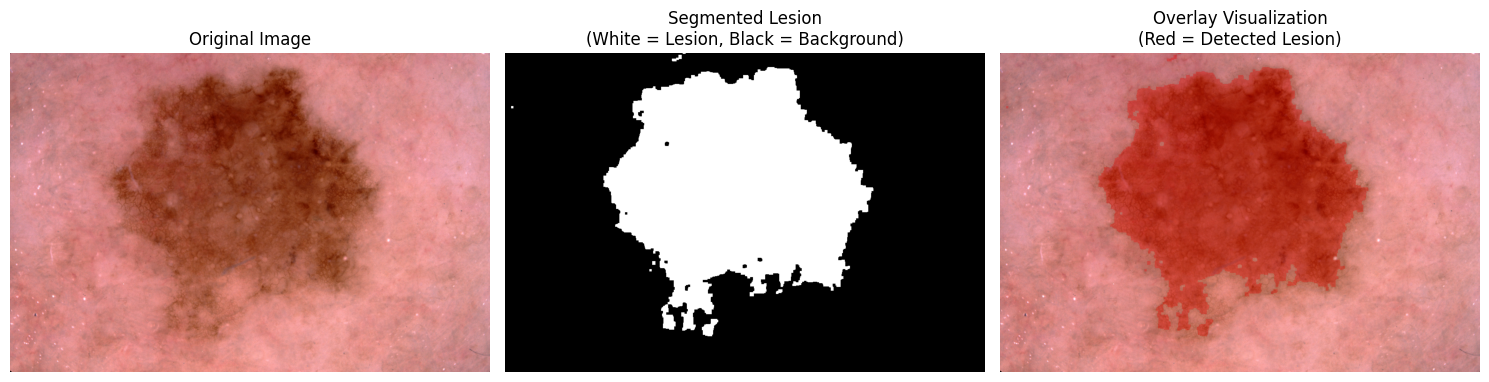


Segmentation Statistics:
  Lesion pixels: 197,982 (28.39% of image)
  Background pixels: 499,362 (71.61% of image)


In [12]:
# Test feature extraction on a sample
# Check if train_images exists
if 'train_images' not in globals() or len(train_images) == 0:
    raise NameError("train_images not defined. Please run Cell 6 first to create train/val/test splits!")

sample_img_path = train_images[0]
sample_img = Image.open(sample_img_path).convert('RGB')

features = feature_extractor.extract_all_features(sample_img)
print("Extracted features from sample image:")
for key, value in features.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Visualize segmentation with better visualization
binary = feature_extractor.segment_lesion(sample_img)
img_array = np.array(sample_img)

# Create overlay visualization
overlay = img_array.copy()
# Create colored mask (red overlay for lesion)
mask = binary > 128
overlay[mask] = [255, 0, 0]  # Red overlay
overlay_alpha = cv2.addWeighted(img_array, 0.7, overlay, 0.3, 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title("Original Image", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap='gray')
plt.title("Segmented Lesion\n(White = Lesion, Black = Background)", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(overlay_alpha)
plt.title("Overlay Visualization\n(Red = Detected Lesion)", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

# Print segmentation statistics
lesion_pixels = np.sum(binary > 128)
total_pixels = binary.size
lesion_percentage = (lesion_pixels / total_pixels) * 100
print(f"\nSegmentation Statistics:")
print(f"  Lesion pixels: {lesion_pixels:,} ({lesion_percentage:.2f}% of image)")
print(f"  Background pixels: {total_pixels - lesion_pixels:,} ({100 - lesion_percentage:.2f}% of image)")

## Section 4: Vision Transformer (ViT) Model

Build a ViT-based model with temporal attention for comparing baseline and follow-up images. We'll use the `timm` library for the ViT backbone.

In [13]:
# Install timm if not available
try:
    import timm
    print(f"timm version: {timm.__version__}")
except ImportError:
    print("Installing timm...")
    import subprocess
    subprocess.check_call(["pip", "install", "timm"])
    import timm
    print("timm installed successfully")

# Check available ViT models
print("\nAvailable ViT models in timm:")
vit_models = [m for m in timm.list_models() if 'vit' in m.lower()]
for model in vit_models[:10]:
    print(f"  {model}")

timm version: 1.0.22

Available ViT models in timm:
  convit_base
  convit_small
  convit_tiny
  crossvit_9_240
  crossvit_9_dagger_240
  crossvit_15_240
  crossvit_15_dagger_240
  crossvit_15_dagger_408
  crossvit_18_240
  crossvit_18_dagger_240


In [14]:
# Build ViT-based change detection model
import timm
from torch.nn import functional as F

class TemporalChangeDetectionViT(nn.Module):
    """
    Vision Transformer for temporal change detection in skin lesions.
    Compares baseline and follow-up images to detect clinically concerning changes.
    """
    
    def __init__(self, 
                 model_name='vit_base_patch16_224',
                 num_classes=4,  # none, minor, moderate, significant
                 pretrained=True,
                 dropout=0.1):
        super(TemporalChangeDetectionViT, self).__init__()
        
        # Load pretrained ViT encoder
        self.encoder = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,  # Remove classification head
            global_pool=''
        )
        
        # Get embedding dimension
        self.embed_dim = self.encoder.embed_dim
        
        # Temporal comparison module
        # Compare features from baseline and followup
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=self.embed_dim,
            num_heads=8,
            dropout=dropout,
            batch_first=True
        )
        
        # Feature difference computation
        self.feature_fusion = nn.Sequential(
            nn.Linear(self.embed_dim * 2, self.embed_dim),
            nn.LayerNorm(self.embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim // 2),
            nn.LayerNorm(self.embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.embed_dim // 2, num_classes)
        )
        
        # Binary classifier (concerning vs non-concerning)
        self.binary_classifier = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim // 2),
            nn.LayerNorm(self.embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.embed_dim // 2, 1)
        )
    
    def forward(self, baseline, followup):
        """
        Forward pass
        
        Args:
            baseline: (B, C, H, W) baseline image
            followup: (B, C, H, W) follow-up image
        
        Returns:
            multi_class_logits: (B, num_classes) logits for change severity
            binary_logits: (B, 1) logits for concerning vs non-concerning
        """
        # Encode both images
        baseline_features = self.encoder.forward_features(baseline)  # (B, N, D)
        followup_features = self.encoder.forward_features(followup)  # (B, N, D)
        
        # Temporal attention: attend to differences
        # Use followup as query, baseline as key/value
        attended_features, _ = self.temporal_attention(
            followup_features,  # query
            baseline_features,   # key
            baseline_features    # value
        )
        
        # Compute feature differences
        # Global average pooling
        baseline_pooled = baseline_features.mean(dim=1)  # (B, D)
        followup_pooled = followup_features.mean(dim=1)  # (B, D)
        attended_pooled = attended_features.mean(dim=1)  # (B, D)
        
        # Concatenate features
        fused_features = torch.cat([baseline_pooled, followup_pooled], dim=1)  # (B, 2*D)
        fused_features = self.feature_fusion(fused_features)  # (B, D)
        
        # Add attended features
        fused_features = fused_features + attended_pooled
        
        # Classification
        multi_class_logits = self.classifier(fused_features)  # (B, num_classes)
        binary_logits = self.binary_classifier(fused_features)  # (B, 1)
        
        return multi_class_logits, binary_logits

# Create model
model = TemporalChangeDetectionViT(
    model_name='vit_base_patch16_224',
    num_classes=4,
    pretrained=True
).to(device)

print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Test forward pass
model.eval()
with torch.no_grad():
    sample_baseline = sample['baseline'].unsqueeze(0).to(device)
    sample_followup = sample['followup'].unsqueeze(0).to(device)
    multi_logits, binary_logits = model(sample_baseline, sample_followup)
    print(f"\nTest forward pass:")
    print(f"  Multi-class logits shape: {multi_logits.shape}")
    print(f"  Binary logits shape: {binary_logits.shape}")
    print(f"  Multi-class predictions: {torch.softmax(multi_logits, dim=1)}")
    print(f"  Binary prediction: {torch.sigmoid(binary_logits)}")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model created with 89,937,029 parameters
Trainable parameters: 89,937,029

Test forward pass:
  Multi-class logits shape: torch.Size([1, 4])
  Binary logits shape: torch.Size([1, 1])
  Multi-class predictions: tensor([[0.2082, 0.2163, 0.1486, 0.4270]], device='cuda:0')
  Binary prediction: tensor([[0.4097]], device='cuda:0')


## Quick Bootstrap for Section 5 (skip earlier cells)
Use this if you want to run Section 5 without executing Sections 1–4. Set `dataset_root` to the folder containing the ISIC images, then run this cell. It will rebuild transforms, splits, simulated temporal pairs, and the ViT model. If `best_change_detection_model.pth` exists, it will be loaded automatically.

### Section 5 Fast/Debug Toggles
If Section 5 hangs, use these toggles. Defaults favor stability (fewer workers, smaller batches, no torch.compile).

In [3]:
# Debug/fast settings for Section 5
FAST_DEBUG = True          # True = safer/less likely to hang (smaller batch, workers=0)
BATCH_SIZE_OVERRIDE = 8    # None to auto; keep small if FAST_DEBUG
NUM_WORKERS_OVERRIDE = 0   # None to auto; 0 avoids multiprocessing hangs
DISABLE_COMPILE = True     # True = skip torch.compile (can be slow/hang in some envs)


In [4]:
# Quick bootstrap to enable Section 5 without running Sections 1–4
# Set this to your ISIC-2019 image root (folder containing images)
dataset_root = '/root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1'

import os, sys, json, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import cv2

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    if torch.cuda.device_count() > 1:
        gpu_memory = [torch.cuda.get_device_properties(i).total_memory for i in range(torch.cuda.device_count())]
        best_gpu = int(np.argmax(gpu_memory))
        device = torch.device(f'cuda:{best_gpu}')
        print(f"Using GPU {best_gpu}: {torch.cuda.get_device_name(best_gpu)}")
    else:
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("No GPU detected, using CPU (slower)")
print(f"Device: {device}")

# Verify dataset_root
root = Path(dataset_root).expanduser()
if not root.exists():
    raise FileNotFoundError(f"dataset_root not found: {root}. Please set the correct path.")
print(f"Dataset root: {root}")

# Collect image files
image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
image_files = []
for ext in image_extensions:
    image_files.extend(list(root.rglob(f"*{ext}")))
if len(image_files) == 0:
    raise RuntimeError(f"No images found under {root}. Check dataset_root.")
print(f"Found {len(image_files)} images")

# Transforms
image_size = 224
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize,
])
val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    normalize,
])

# Temporal simulator (same as earlier, simplified)
class TemporalLesionSimulator:
    def __init__(self, image_size=224):
        self.image_size = image_size
    def apply_size_growth(self, image, growth_factor=1.0):
        if growth_factor <= 1.0:
            return image
        img_array = np.array(image)
        h, w = img_array.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, 0, growth_factor)
        new_w, new_h = int(w * growth_factor), int(h * growth_factor)
        img_scaled = cv2.warpAffine(img_array, M, (new_w, new_h))
        if new_w > w or new_h > h:
            start_x = (new_w - w) // 2
            start_y = (new_h - h) // 2
            img_scaled = img_scaled[start_y:start_y+h, start_x:start_x+w]
        else:
            pad_x = (w - new_w) // 2
            pad_y = (h - new_h) // 2
            img_scaled = cv2.copyMakeBorder(img_scaled, pad_y, h-new_h-pad_y, pad_x, w-new_w-pad_x, cv2.BORDER_REPLICATE)
        return Image.fromarray(img_scaled)
    def apply_border_irregularity(self, image, irregularity=0.0):
        if irregularity == 0:
            return image
        img_array = np.array(image)
        h, w = img_array.shape[:2]
        noise = np.random.randn(h, w, 2) * irregularity * 10
        map_x = np.float32(np.arange(w).reshape(1, -1) + noise[:, :, 0])
        map_y = np.float32(np.arange(h).reshape(-1, 1) + noise[:, :, 1])
        img_distorted = cv2.remap(img_array, map_x, map_y, cv2.INTER_LINEAR)
        return Image.fromarray(img_distorted)
    def apply_color_variation(self, image, darken_factor=0.0, color_shift=0.0):
        img_array = np.array(image).astype(np.float32)
        if darken_factor > 0:
            img_array = img_array * (1 - darken_factor * 0.3)
        if color_shift > 0:
            shift = np.random.randn(3) * color_shift * 20
            img_array[:, :, 0] = np.clip(img_array[:, :, 0] + shift[0], 0, 255)
            img_array[:, :, 1] = np.clip(img_array[:, :, 1] + shift[1], 0, 255)
            img_array[:, :, 2] = np.clip(img_array[:, :, 2] + shift[2], 0, 255)
        img_array = np.clip(img_array, 0, 255).astype(np.uint8)
        return Image.fromarray(img_array)
    def apply_shape_asymmetry(self, image, asymmetry=0.0):
        if asymmetry == 0:
            return image
        img_array = np.array(image)
        h, w = img_array.shape[:2]
        center = (w // 2, h // 2)
        angle = asymmetry * 5
        scale_x = 1.0 + asymmetry * 0.1
        scale_y = 1.0 - asymmetry * 0.05
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        M[0, 0] *= scale_x
        M[1, 1] *= scale_y
        img_transformed = cv2.warpAffine(img_array, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
        return Image.fromarray(img_transformed)
    def generate_followup(self, baseline_image, change_severity='none'):
        followup = baseline_image.copy()
        if change_severity == 'none':
            return followup
        elif change_severity == 'minor':
            followup = self.apply_size_growth(followup, growth_factor=1.05)
            followup = self.apply_border_irregularity(followup, irregularity=0.02)
            followup = self.apply_color_variation(followup, darken_factor=0.05, color_shift=0.02)
        elif change_severity == 'moderate':
            followup = self.apply_size_growth(followup, growth_factor=1.12)
            followup = self.apply_border_irregularity(followup, irregularity=0.05)
            followup = self.apply_color_variation(followup, darken_factor=0.10, color_shift=0.05)
            followup = self.apply_shape_asymmetry(followup, asymmetry=0.03)
        elif change_severity == 'significant':
            followup = self.apply_size_growth(followup, growth_factor=1.20)
            followup = self.apply_border_irregularity(followup, irregularity=0.10)
            followup = self.apply_color_variation(followup, darken_factor=0.15, color_shift=0.10)
            followup = self.apply_shape_asymmetry(followup, asymmetry=0.06)
        return followup

simulator = TemporalLesionSimulator(image_size=image_size)

# Temporal pair dataset
class TemporalPairDataset(Dataset):
    def __init__(self, image_paths, simulator, transform=None, change_distribution=None):
        self.image_paths = image_paths
        self.simulator = simulator
        self.transform = transform
        if change_distribution is None:
            change_distribution = {'none': 0.4, 'minor': 0.3, 'moderate': 0.2, 'significant': 0.1}
        self.change_distribution = change_distribution
        self.severity_to_class = {'none': 0, 'minor': 1, 'moderate': 2, 'significant': 3}
        np.random.seed(42)
        self.change_labels = []
        for _ in range(len(image_paths)):
            r = np.random.random()
            cumsum = 0
            for sev, p in change_distribution.items():
                cumsum += p
                if r <= cumsum:
                    self.change_labels.append(self.severity_to_class[sev])
                    break
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            baseline = Image.open(img_path).convert('RGB')
        except Exception as e:
            baseline = Image.new('RGB', (image_size, image_size))
        change_class = self.change_labels[idx]
        severity_str = [k for k, v in self.severity_to_class.items() if v == change_class][0]
        followup = self.simulator.generate_followup(baseline, change_severity=severity_str)
        if self.transform:
            baseline = self.transform(baseline)
            followup = self.transform(followup)
        binary_label = 1 if change_class >= 2 else 0
        return {
            'baseline': baseline,
            'followup': followup,
            'change_class': change_class,
            'binary_label': binary_label
        }

# Split data (limit to manageable size)
MAX_SAMPLES = 4000 if len(image_files) > 4000 else len(image_files)
indices = np.random.permutation(len(image_files))[:MAX_SAMPLES]
selected_images = [str(image_files[i]) for i in indices]
train_images, temp_images = train_test_split(selected_images, test_size=0.3, random_state=42)
val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)
print(f"Using {MAX_SAMPLES} images -> Train {len(train_images)}, Val {len(val_images)}, Test {len(test_images)}")

train_pair_dataset = TemporalPairDataset(train_images, simulator, transform=train_transform)
val_pair_dataset = TemporalPairDataset(val_images, simulator, transform=val_transform)
test_pair_dataset = TemporalPairDataset(test_images, simulator, transform=val_transform)
print("Temporal pair datasets ready")

# Model definition (same as Section 4)
try:
    import timm
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'timm'])
    import timm

class TemporalChangeDetectionViT(nn.Module):
    def __init__(self, model_name='vit_base_patch16_224', num_classes=4, pretrained=True, dropout=0.1):
        super().__init__()
        self.encoder = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='')
        self.embed_dim = self.encoder.embed_dim
        self.temporal_attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=8, dropout=dropout, batch_first=True)
        self.feature_fusion = nn.Sequential(
            nn.Linear(self.embed_dim * 2, self.embed_dim),
            nn.LayerNorm(self.embed_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim // 2),
            nn.LayerNorm(self.embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.embed_dim // 2, num_classes)
        )
        self.binary_classifier = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim // 2),
            nn.LayerNorm(self.embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.embed_dim // 2, 1)
        )
    def forward(self, baseline, followup):
        baseline_features = self.encoder.forward_features(baseline)
        followup_features = self.encoder.forward_features(followup)
        attended_features, _ = self.temporal_attention(followup_features, baseline_features, baseline_features)
        baseline_pooled = baseline_features.mean(dim=1)
        followup_pooled = followup_features.mean(dim=1)
        attended_pooled = attended_features.mean(dim=1)
        fused_features = torch.cat([baseline_pooled, followup_pooled], dim=1)
        fused_features = self.feature_fusion(fused_features)
        fused_features = fused_features + attended_pooled
        multi_class_logits = self.classifier(fused_features)
        binary_logits = self.binary_classifier(fused_features)
        return multi_class_logits, binary_logits

model = TemporalChangeDetectionViT().to(device)
print("Model created")

# Load checkpoint if available
ckpt_path = Path('best_change_detection_model.pth')
if ckpt_path.exists():
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"Loaded checkpoint: {ckpt_path}")
else:
    print("No checkpoint found; starting from scratch")

print("Bootstrap complete: model, datasets, transforms, device are ready for Section 5.")

Using GPU: NVIDIA A100-SXM4-80GB
Device: cuda
Dataset root: /root/.cache/kagglehub/datasets/agsam23/isic-2019-challenge/versions/1
Found 33569 images
Using 4000 images -> Train 2800, Val 600, Test 600
Temporal pair datasets ready


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Model created
No checkpoint found; starting from scratch
Bootstrap complete: model, datasets, transforms, device are ready for Section 5.


## Section 5: Training Pipeline

Set up training with focal loss, data augmentation, train/validation loops, and evaluation metrics.

In [12]:
# Install tqdm for progress bars if not available
try:
    from tqdm import tqdm
    print("tqdm available for progress bars")
except ImportError:
    print("Installing tqdm for progress bars...")
    import subprocess
    subprocess.check_call(["pip", "install", "-q", "tqdm"])
    from tqdm import tqdm
    print("tqdm installed")

tqdm available for progress bars


In [13]:
# Focal Loss implementation
# Minimal imports so Section 5 can run standalone (model/data must still exist)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch.utils.data import DataLoader

# Ensure required objects from earlier sections are present
required_objs = ['model', 'train_pair_dataset', 'val_pair_dataset', 'test_pair_dataset']
missing = [r for r in required_objs if r not in globals()]
if missing:
    raise NameError(
        f"Missing {missing}. Please run Sections 1-4 (data loading, simulation, feature extraction, model) before Section 5."
    )

# Ensure device exists
if 'device' not in globals():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"device not set earlier; defaulting to {device}")

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        # Ensure functional is available even if cell order caused missing import
        from torch.nn import functional as F
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Combined loss function
class CombinedLoss(nn.Module):
    """Combined loss: multi-class focal loss + binary BCE loss"""
    def __init__(self, alpha=1, gamma=2, multi_weight=0.7, binary_weight=0.3):
        super(CombinedLoss, self).__init__()
        self.multi_class_loss = FocalLoss(alpha=alpha, gamma=gamma)
        self.binary_loss = nn.BCEWithLogitsLoss()
        self.multi_weight = multi_weight
        self.binary_weight = binary_weight
    
    def forward(self, multi_logits, binary_logits, multi_targets, binary_targets):
        multi_loss = self.multi_class_loss(multi_logits, multi_targets)
        binary_loss = self.binary_loss(binary_logits.squeeze(), binary_targets.float())
        
        total_loss = self.multi_weight * multi_loss + self.binary_weight * binary_loss
        return total_loss, multi_loss, binary_loss

# Create data loaders with optimizations
# Increase batch size if GPU has enough memory
batch_size = 32 if torch.cuda.is_available() else 16
num_workers = 4 if torch.cuda.is_available() else 2  # More workers for faster data loading
pin_memory = torch.cuda.is_available()  # Faster GPU transfer

print(f"Batch size: {batch_size}")
print(f"Number of workers: {num_workers}")
print(f"Pin memory: {pin_memory}")

train_loader = DataLoader(
    train_pair_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False  # Keep workers alive
)
val_loader = DataLoader(
    val_pair_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)
test_loader = DataLoader(
    test_pair_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"Data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Batch size: 32
Number of workers: 4
Pin memory: True
Data loaders created:
  Train batches: 88
  Validation batches: 19
  Test batches: 19


In [16]:
# Training setup with safeguards
from pathlib import Path

# Ensure model exists and is a nn.Module
if 'model' not in globals() or not isinstance(model, nn.Module):
    if 'TemporalChangeDetectionViT' not in globals():
        raise NameError("TemporalChangeDetectionViT is not defined. Run the model definition/bootstrap cell first.")
    print("Model was missing or invalid; rebuilding a fresh model...")
    model = TemporalChangeDetectionViT().to(device)
    ckpt_path = Path('best_change_detection_model.pth')
    if ckpt_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"Loaded checkpoint: {ckpt_path}")
    else:
        print("No checkpoint found; training from scratch")

criterion = CombinedLoss(alpha=1, gamma=2, multi_weight=0.7, binary_weight=0.3)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)  # verbose not supported in this torch version

# Enable mixed precision training for faster training (if GPU available)
use_amp = torch.cuda.is_available()  # Automatic Mixed Precision
scaler = torch.cuda.amp.GradScaler() if use_amp else None

# Try to compile model (optional)
if hasattr(torch, 'compile') and torch.cuda.is_available() and not DISABLE_COMPILE:
    try:
        print("Compiling model with torch.compile for faster training...")
        model = torch.compile(model, mode='reduce-overhead')
        print("Model compiled successfully!")
    except Exception as e:
        print(f"Could not compile model: {e}")
        print("Continuing without compilation...")
else:
    print("torch.compile disabled (DISABLE_COMPILE=True or no CUDA)")

if use_amp:
    print("Mixed precision training enabled (faster training with minimal accuracy loss)")
else:
    print("Mixed precision training disabled (CPU mode or not available)")

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    multi_loss_total = 0
    binary_loss_total = 0
    
    correct_multi = 0
    correct_binary = 0
    total_samples = 0
    
    for batch_idx, batch in enumerate(loader):
        baseline = batch['baseline'].to(device)
        followup = batch['followup'].to(device)
        multi_targets = batch['change_class'].to(device)
        binary_targets = batch['binary_label'].to(device)
        
        optimizer.zero_grad()
        
        multi_logits, binary_logits = model(baseline, followup)
        
        loss, multi_loss, binary_loss = criterion(
            multi_logits, binary_logits, multi_targets, binary_targets
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        multi_loss_total += multi_loss.item()
        binary_loss_total += binary_loss.item()
        
        # Accuracy
        pred_multi = multi_logits.argmax(dim=1)
        pred_binary = (torch.sigmoid(binary_logits.squeeze()) > 0.5).long()
        
        correct_multi += (pred_multi == multi_targets).sum().item()
        correct_binary += (pred_binary == binary_targets).sum().item()
        total_samples += multi_targets.size(0)
    
    avg_loss = total_loss / len(loader)
    avg_multi_loss = multi_loss_total / len(loader)
    avg_binary_loss = binary_loss_total / len(loader)
    acc_multi = correct_multi / total_samples
    acc_binary = correct_binary / total_samples
    
    return avg_loss, avg_multi_loss, avg_binary_loss, acc_multi, acc_binary

# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    multi_loss_total = 0
    binary_loss_total = 0
    
    correct_multi = 0
    correct_binary = 0
    total_samples = 0
    
    all_multi_preds = []
    all_multi_targets = []
    all_binary_preds = []
    all_binary_targets = []
    all_binary_probs = []
    
    with torch.no_grad():
        for batch in loader:
            baseline = batch['baseline'].to(device)
            followup = batch['followup'].to(device)
            multi_targets = batch['change_class'].to(device)
            binary_targets = batch['binary_label'].to(device)
            
            multi_logits, binary_logits = model(baseline, followup)
            
            loss, multi_loss, binary_loss = criterion(
                multi_logits, binary_logits, multi_targets, binary_targets
            )
            
            total_loss += loss.item()
            multi_loss_total += multi_loss.item()
            binary_loss_total += binary_loss.item()
            
            # Predictions
            pred_multi = multi_logits.argmax(dim=1)
            pred_binary = (torch.sigmoid(binary_logits.squeeze()) > 0.5).long()
            prob_binary = torch.sigmoid(binary_logits.squeeze())
            
            correct_multi += (pred_multi == multi_targets).sum().item()
            correct_binary += (pred_binary == binary_targets).sum().item()
            total_samples += multi_targets.size(0)
            
            # Store for metrics
            all_multi_preds.extend(pred_multi.cpu().numpy())
            all_multi_targets.extend(multi_targets.cpu().numpy())
            all_binary_preds.extend(pred_binary.cpu().numpy())
            all_binary_targets.extend(binary_targets.cpu().numpy())
            all_binary_probs.extend(prob_binary.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    avg_multi_loss = multi_loss_total / len(loader)
    avg_binary_loss = binary_loss_total / len(loader)
    acc_multi = correct_multi / total_samples
    acc_binary = correct_binary / total_samples
    
    # Calculate ROC-AUC for binary classification
    from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
    
    try:
        roc_auc = roc_auc_score(all_binary_targets, all_binary_probs)
    except:
        roc_auc = 0.0
    
    cm_multi = confusion_matrix(all_multi_targets, all_multi_preds)
    cm_binary = confusion_matrix(all_binary_targets, all_binary_preds)
    
    return {
        'loss': avg_loss,
        'multi_loss': avg_multi_loss,
        'binary_loss': avg_binary_loss,
        'acc_multi': acc_multi,
        'acc_binary': acc_binary,
        'roc_auc': roc_auc,
        'cm_multi': cm_multi,
        'cm_binary': cm_binary,
        'multi_preds': all_multi_preds,
        'multi_targets': all_multi_targets,
        'binary_preds': all_binary_preds,
        'binary_targets': all_binary_targets,
        'binary_probs': all_binary_probs
    }

print("Training functions defined")

Model was missing or invalid; rebuilding a fresh model...
No checkpoint found; training from scratch
torch.compile disabled (DISABLE_COMPILE=True or no CUDA)
Mixed precision training enabled (faster training with minimal accuracy loss)
Training functions defined


/tmp/ipython-input-372763030.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp else None


In [17]:
# Training loop
num_epochs = 10  # Adjust based on needs
best_val_loss = float('inf')
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Starting training...")
print(f"Device: {device}")
print(f"Number of epochs: {num_epochs}")
print("-" * 60)

for epoch in range(num_epochs):
    # Train
    train_loss, train_multi_loss, train_binary_loss, train_acc_multi, train_acc_binary = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_metrics = validate(model, val_loader, criterion, device)
    
    # Learning rate scheduling
    scheduler.step(val_metrics['loss'])
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_metrics['loss'])
    train_accs.append(train_acc_binary)
    val_accs.append(val_metrics['acc_binary'])
    
    # Print progress
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train - Loss: {train_loss:.4f} | Multi Acc: {train_acc_multi:.4f} | Binary Acc: {train_acc_binary:.4f}")
    print(f"  Val   - Loss: {val_metrics['loss']:.4f} | Multi Acc: {val_metrics['acc_multi']:.4f} | Binary Acc: {val_metrics['acc_binary']:.4f} | ROC-AUC: {val_metrics['roc_auc']:.4f}")
    
    # Save best model
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), 'best_change_detection_model.pth')
        print(f"  ✓ Saved best model (val_loss: {best_val_loss:.4f})")
    
    print("-" * 60)

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...
Device: cuda
Number of epochs: 10
------------------------------------------------------------
Epoch 1/10
  Train - Loss: 0.7006 | Multi Acc: 0.3786 | Binary Acc: 0.7011
  Val   - Loss: 0.6742 | Multi Acc: 0.4067 | Binary Acc: 0.6900 | ROC-AUC: 0.5882
  ✓ Saved best model (val_loss: 0.6742)
------------------------------------------------------------
Epoch 2/10
  Train - Loss: 0.6754 | Multi Acc: 0.3886 | Binary Acc: 0.7029
  Val   - Loss: 0.6837 | Multi Acc: 0.2833 | Binary Acc: 0.6900 | ROC-AUC: 0.6235
------------------------------------------------------------
Epoch 3/10
  Train - Loss: 0.6721 | Multi Acc: 0.3761 | Binary Acc: 0.7029
  Val   - Loss: 0.6711 | Multi Acc: 0.4067 | Binary Acc: 0.6900 | ROC-AUC: 0.5978
  ✓ Saved best model (val_loss: 0.6711)
------------------------------------------------------------
Epoch 4/10
  Train - Loss: 0.6666 | Multi Acc: 0.3939 | Binary Acc: 0.7054
  Val   - Loss: 0.6739 | Multi Acc: 0.4067 | Binary Acc: 0.6900 | ROC-AUC: 

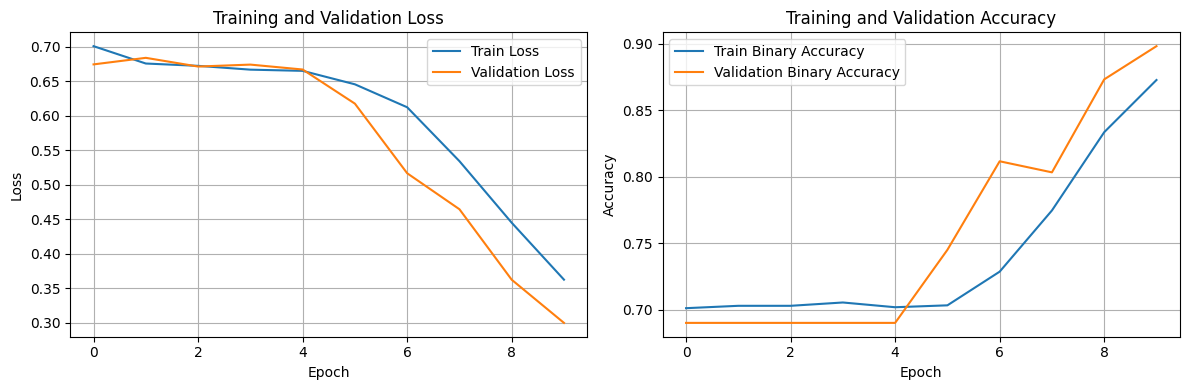

In [20]:
# Plot training curves
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Binary Accuracy')
plt.plot(val_accs, label='Validation Binary Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Evaluate on test set
print("Evaluating on test set...")
model.load_state_dict(torch.load('best_change_detection_model.pth'))
test_metrics = validate(model, test_loader, criterion, device)

print(f"\nTest Set Results:")
print(f"  Loss: {test_metrics['loss']:.4f}")
print(f"  Multi-class Accuracy: {test_metrics['acc_multi']:.4f}")
print(f"  Binary Accuracy: {test_metrics['acc_binary']:.4f}")
print(f"  ROC-AUC: {test_metrics['roc_auc']:.4f}")

# Confusion matrices
from sklearn.metrics import classification_report

print("\nMulti-class Confusion Matrix:")
print(test_metrics['cm_multi'])
print("\nMulti-class Classification Report:")
print(classification_report(test_metrics['multi_targets'], test_metrics['multi_preds'], 
                           target_names=['None', 'Minor', 'Moderate', 'Significant']))

print("\nBinary Confusion Matrix:")
print(test_metrics['cm_binary'])
print("\nBinary Classification Report:")
print(classification_report(test_metrics['binary_targets'], test_metrics['binary_preds'], 
                           target_names=['Non-concerning', 'Concerning']))

Evaluating on test set...

Test Set Results:
  Loss: 0.3244
  Multi-class Accuracy: 0.7650
  Binary Accuracy: 0.9150
  ROC-AUC: 0.9533

Multi-class Confusion Matrix:
[[244   0   0   0]
 [ 42 120   7   1]
 [  4  28  82   4]
 [  6   2  47  13]]

Multi-class Classification Report:
              precision    recall  f1-score   support

        None       0.82      1.00      0.90       244
       Minor       0.80      0.71      0.75       170
    Moderate       0.60      0.69      0.65       118
 Significant       0.72      0.19      0.30        68

    accuracy                           0.77       600
   macro avg       0.74      0.65      0.65       600
weighted avg       0.76      0.77      0.74       600


Binary Confusion Matrix:
[[407   7]
 [ 44 142]]

Binary Classification Report:
                precision    recall  f1-score   support

Non-concerning       0.90      0.98      0.94       414
    Concerning       0.95      0.76      0.85       186

      accuracy                      

In [33]:
# Ensure feature_extractor exists (for feature evolution plots)
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn

if 'feature_extractor' not in globals():
    class LesionFeatureExtractor:
        """Extract clinically relevant features from skin lesion images"""
        def __init__(self):
            pass
        def segment_lesion(self, image):
            if isinstance(image, Image.Image):
                img_array = np.array(image)
            else:
                img_array = image.copy()
            gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) if len(img_array.shape)==3 else img_array
            _, binary1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            _, binary2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            binary3 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
            h, w = gray.shape
            center_region = (h//4, w//4, h//2, w//2)
            def center_score(b):
                y1, x1, y2, x2 = center_region
                patch = b[y1:y1+y2, x1:x1+x2]
                return np.sum(patch>128)
            scores = [center_score(b) for b in [binary1,binary2,binary3]]
            binary = [binary1,binary2,binary3][int(np.argmax(scores))]
            kernel = np.ones((5,5), np.uint8)
            binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
            binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
            if np.sum(binary>128)/binary.size > 0.7:
                binary = cv2.bitwise_not(binary)
            return binary
        def extract_shape_features(self, image):
            binary = self.segment_lesion(image)
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours)==0:
                return {'area':0,'perimeter':0,'asymmetry_index':0,'circularity':0}
            contour = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(contour)
            peri = cv2.arcLength(contour, True)
            circ = (4*np.pi*area)/(peri**2) if peri>0 else 0
            x,y,w,h = cv2.boundingRect(contour)
            bbox_area = w*h
            asym = 1 - (area/(bbox_area+1e-6)) if bbox_area>0 else 0
            return {'area':area,'perimeter':peri,'asymmetry_index':asym,'circularity':circ}
        def extract_border_features(self, image):
            binary = self.segment_lesion(image)
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours)==0:
                return {'border_irregularity':0,'edge_smoothness':0}
            contour = max(contours, key=cv2.contourArea)
            hull = cv2.convexHull(contour)
            hull_peri = cv2.arcLength(hull, True)
            actual_peri = cv2.arcLength(contour, True)
            irregularity = (actual_peri/(hull_peri+1e-6)) if hull_peri>0 else 0
            M = cv2.moments(contour)
            if M['m00']>0:
                cx = int(M['m10']/M['m00']); cy = int(M['m01']/M['m00'])
                distances = [np.sqrt((pt[0][0]-cx)**2 + (pt[0][1]-cy)**2) for pt in contour]
                smoothness = 1.0/(1.0+np.std(distances)) if len(distances)>0 else 0
            else:
                smoothness = 0
            return {'border_irregularity':irregularity,'edge_smoothness':smoothness}
        def extract_color_features(self, image):
            img_array = np.array(image)
            color_variance = {'r_variance':np.var(img_array[:,:,0]),'g_variance':np.var(img_array[:,:,1]),'b_variance':np.var(img_array[:,:,2])}
            total_var = np.var(img_array.reshape(-1,3), axis=0).mean()
            hist_r = np.histogram(img_array[:,:,0], bins=32, range=(0,256))[0]
            hist_g = np.histogram(img_array[:,:,1], bins=32, range=(0,256))[0]
            hist_b = np.histogram(img_array[:,:,2], bins=32, range=(0,256))[0]
            hist_r = hist_r/(hist_r.sum()+1e-6); hist_g = hist_g/(hist_g.sum()+1e-6); hist_b = hist_b/(hist_b.sum()+1e-6)
            def entropy(hist):
                h = hist[hist>0]; return -np.sum(h*np.log2(h+1e-10))
            color_entropy = (entropy(hist_r)+entropy(hist_g)+entropy(hist_b))/3
            return {'color_variance':total_var,'color_entropy':color_entropy,
                    'r_variance':color_variance['r_variance'],'g_variance':color_variance['g_variance'],'b_variance':color_variance['b_variance']}
        def extract_all_features(self, image):
            shape = self.extract_shape_features(image)
            border = self.extract_border_features(image)
            color = self.extract_color_features(image)
            return {**shape, **border, **color}
        def compute_feature_difference(self, baseline_features, followup_features):
            diffs = {}
            for k in baseline_features:
                if isinstance(baseline_features[k], (int,float)):
                    diffs[f'{k}_diff'] = followup_features[k] - baseline_features[k]
                    diffs[f'{k}_ratio'] = followup_features[k]/(baseline_features[k]+1e-6)
            return diffs

    feature_extractor = LesionFeatureExtractor()
    print("feature_extractor was missing; created a new instance.")
else:
    print("feature_extractor already defined; using existing instance.")

feature_extractor was missing; created a new instance.


## Section 6: Visualization and Analysis

Create visualization tools: side-by-side image comparisons, change heatmaps, attention visualizations, and feature evolution plots.

In [34]:
# Visualization functions
def visualize_pair_comparison(baseline_img, followup_img, change_class, binary_label, 
                               model_pred=None, save_path=None):
    """Visualize baseline vs followup with predictions"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Denormalize for display
    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return tensor * std + mean
    
    baseline_display = denormalize(baseline_img).clamp(0, 1)
    followup_display = denormalize(followup_img).clamp(0, 1)
    
    axes[0].imshow(baseline_display.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title(f'Baseline Image\nChange Class: {change_class}', fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(followup_display.permute(1, 2, 0).cpu().numpy())
    title = f'Follow-up Image\nBinary Label: {"Concerning" if binary_label else "Non-concerning"}'
    if model_pred is not None:
        title += f'\nPredicted: {model_pred}'
    axes[1].set_title(title, fontsize=12)
    axes[1].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def visualize_change_heatmap(baseline_img, followup_img, model, device):
    """Create heatmap showing where changes are detected"""
    model.eval()
    
    baseline_tensor = baseline_img.unsqueeze(0).to(device)
    followup_tensor = followup_img.unsqueeze(0).to(device)
    
    # Get attention weights (simplified - using feature differences)
    with torch.no_grad():
        baseline_features = model.encoder.forward_features(baseline_tensor)
        followup_features = model.encoder.forward_features(followup_tensor)
        
        # Compute per-patch differences
        feature_diff = torch.abs(followup_features - baseline_features)
        patch_importance = feature_diff.mean(dim=-1).squeeze().cpu().numpy()
    
    # Reshape to spatial dimensions (14x14 for patch size 16)
    spatial_size = int(np.sqrt(patch_importance.shape[0]))
    patch_importance = patch_importance.reshape(spatial_size, spatial_size)
    
    # Upsample to image size
    import scipy.ndimage
    heatmap = scipy.ndimage.zoom(patch_importance, (224/spatial_size, 224/spatial_size), order=1)
    
    # Denormalize images
    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return tensor * std + mean
    
    followup_display = denormalize(followup_img).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].imshow(followup_display)
    axes[0].set_title('Follow-up Image', fontsize=12)
    axes[0].axis('off')
    
    im = axes[1].imshow(followup_display)
    heatmap_overlay = axes[1].imshow(heatmap, alpha=0.5, cmap='hot', interpolation='bilinear')
    axes[1].set_title('Change Detection Heatmap\n(Hotter = More Change)', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(heatmap_overlay, ax=axes[1], fraction=0.046)
    
    plt.tight_layout()
    plt.show()

def plot_feature_evolution(baseline_img, followup_img, feature_extractor):
    """Plot evolution of shape, border, and color features"""
    # Denormalize helper function
    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return tensor * std + mean
    
    baseline_features = feature_extractor.extract_all_features(
        Image.fromarray((denormalize(baseline_img).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8))
    )
    followup_features = feature_extractor.extract_all_features(
        Image.fromarray((denormalize(followup_img).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8))
    )
    
    # Select key features to plot
    key_features = {
        'Shape': ['area', 'asymmetry_index', 'circularity'],
        'Border': ['border_irregularity', 'edge_smoothness'],
        'Color': ['color_variance', 'color_entropy']
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, (category, features) in enumerate(key_features.items()):
        baseline_vals = [baseline_features.get(f, 0) for f in features]
        followup_vals = [followup_features.get(f, 0) for f in features]
        
        x = np.arange(len(features))
        width = 0.35
        
        axes[idx].bar(x - width/2, baseline_vals, width, label='Baseline', alpha=0.7)
        axes[idx].bar(x + width/2, followup_vals, width, label='Follow-up', alpha=0.7)
        axes[idx].set_xlabel('Features')
        axes[idx].set_ylabel('Value')
        axes[idx].set_title(f'{category} Features Evolution')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(features, rotation=45, ha='right')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Visualization functions defined")

Visualization functions defined


Visualizing sample predictions...

Sample 1:
  True change class: None
  Predicted change class: None
  True binary: Non-concerning
  Predicted binary: Non-concerning (prob: 0.048)


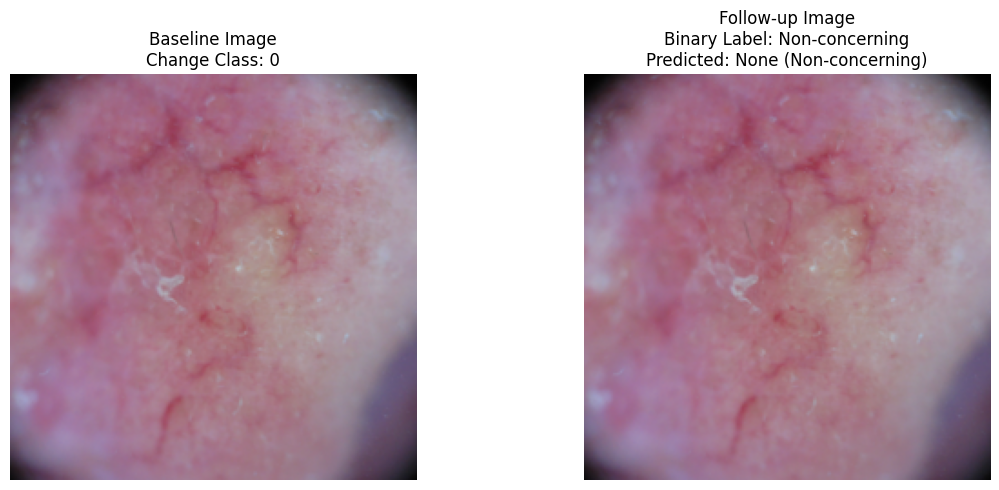


Sample 2:
  True change class: Significant
  Predicted change class: Moderate
  True binary: Concerning
  Predicted binary: Concerning (prob: 0.880)


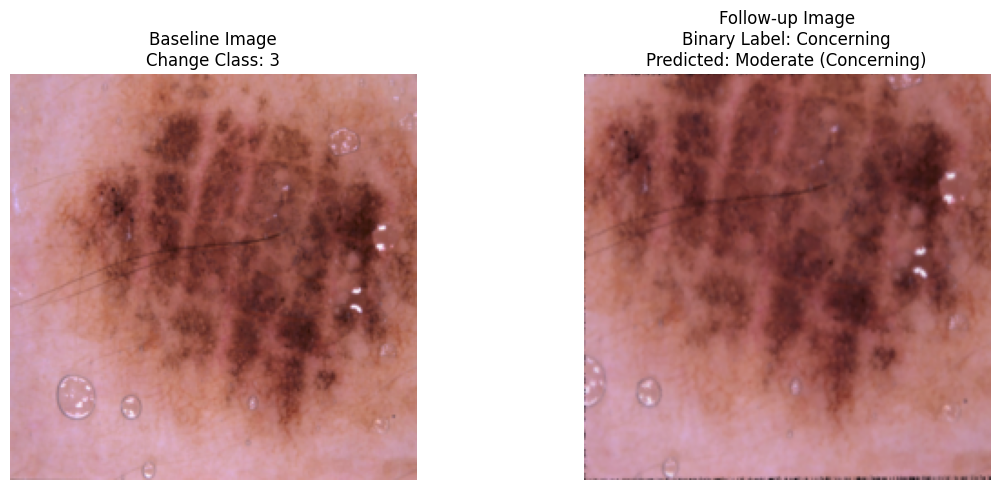


Sample 3:
  True change class: Moderate
  Predicted change class: Moderate
  True binary: Concerning
  Predicted binary: Concerning (prob: 0.621)


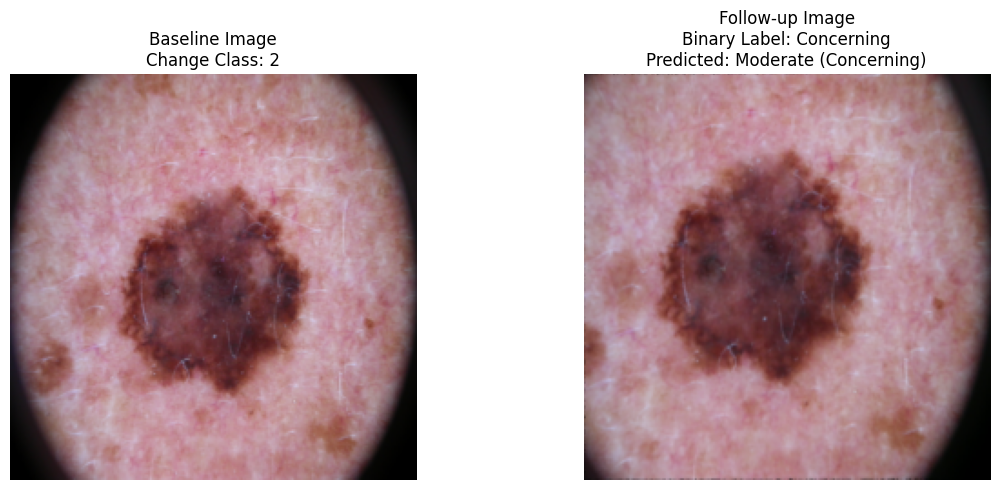


Sample 4:
  True change class: Minor
  Predicted change class: Minor
  True binary: Non-concerning
  Predicted binary: Non-concerning (prob: 0.278)


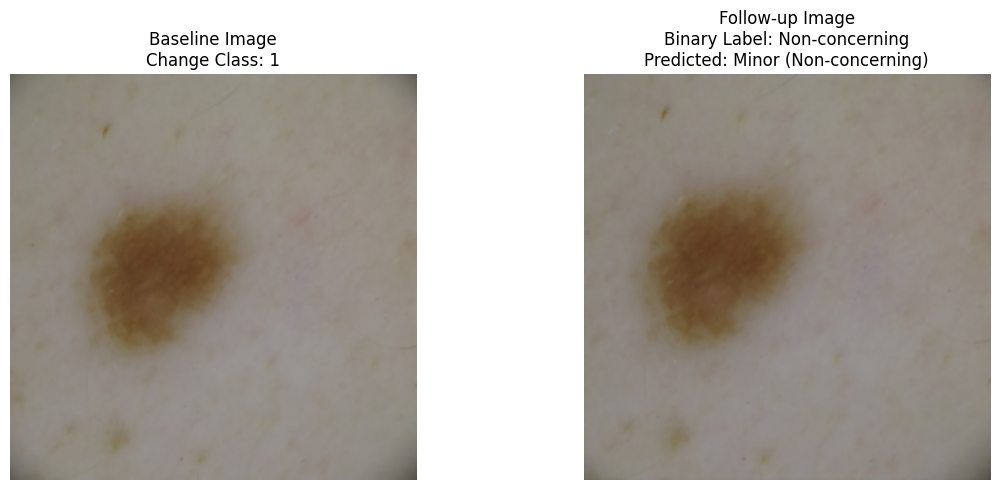


Sample 5:
  True change class: None
  Predicted change class: None
  True binary: Non-concerning
  Predicted binary: Non-concerning (prob: 0.089)


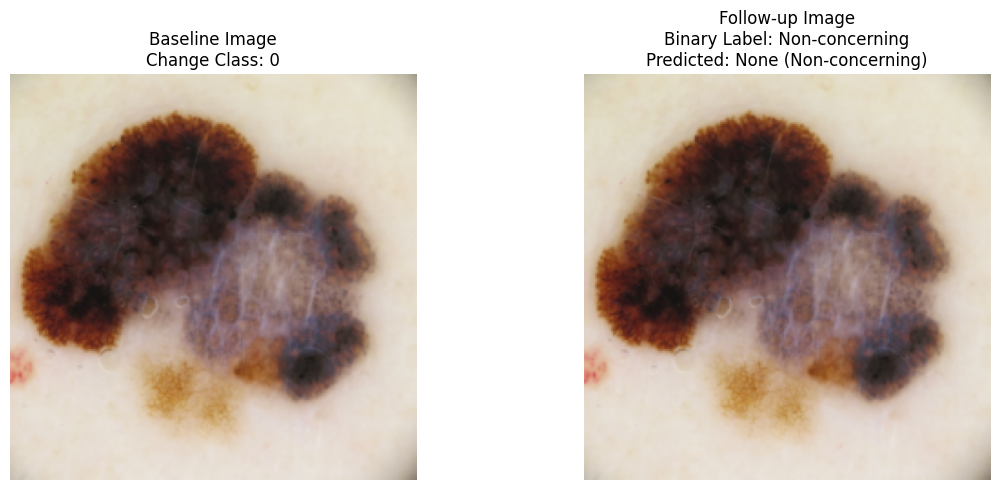

In [35]:
# Visualize sample predictions
model.eval()
num_samples = 5

print("Visualizing sample predictions...")
for i in range(min(num_samples, len(test_pair_dataset))):
    sample = test_pair_dataset[i]
    baseline = sample['baseline'].unsqueeze(0).to(device)
    followup = sample['followup'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        multi_logits, binary_logits = model(baseline, followup)
        pred_class = multi_logits.argmax(dim=1).item()
        pred_binary = (torch.sigmoid(binary_logits.squeeze()) > 0.5).item()
        pred_prob = torch.sigmoid(binary_logits.squeeze()).item()
    
    severity_names = ['None', 'Minor', 'Moderate', 'Significant']
    print(f"\nSample {i+1}:")
    print(f"  True change class: {severity_names[sample['change_class']]}")
    print(f"  Predicted change class: {severity_names[pred_class]}")
    print(f"  True binary: {'Concerning' if sample['binary_label'] else 'Non-concerning'}")
    print(f"  Predicted binary: {'Concerning' if pred_binary else 'Non-concerning'} (prob: {pred_prob:.3f})")
    
    visualize_pair_comparison(
        sample['baseline'], 
        sample['followup'],
        sample['change_class'],
        sample['binary_label'],
        model_pred=f"{severity_names[pred_class]} ({'Concerning' if pred_binary else 'Non-concerning'})"
    )


Visualizing change heatmaps for concerning cases...


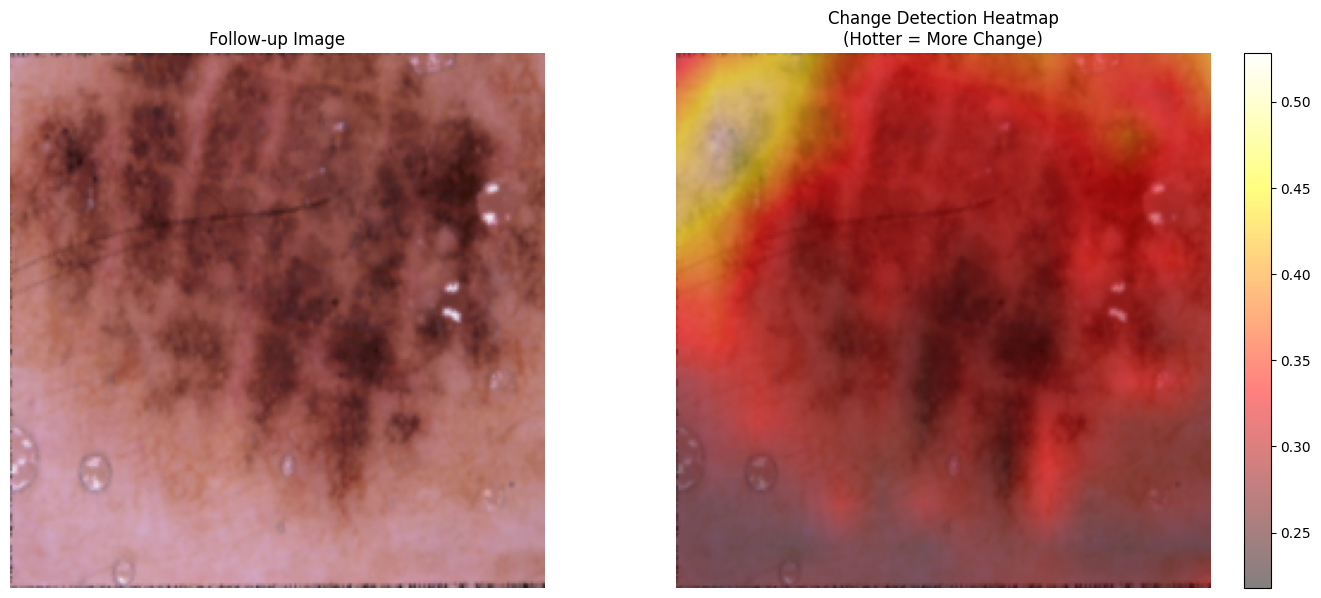

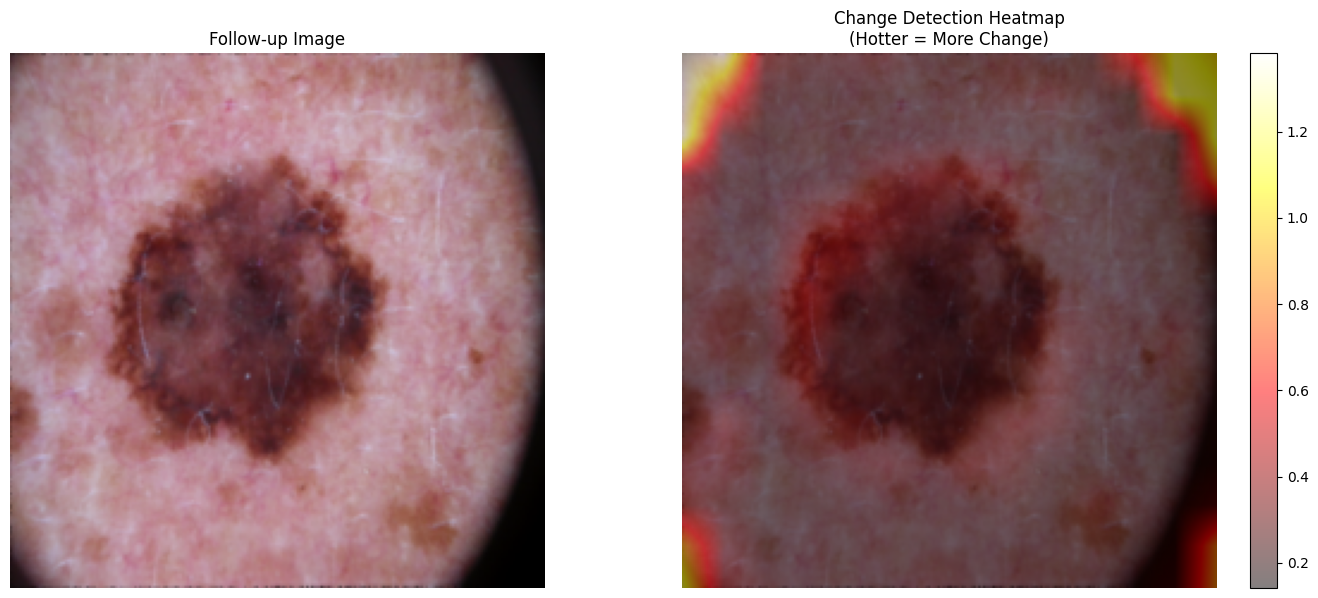

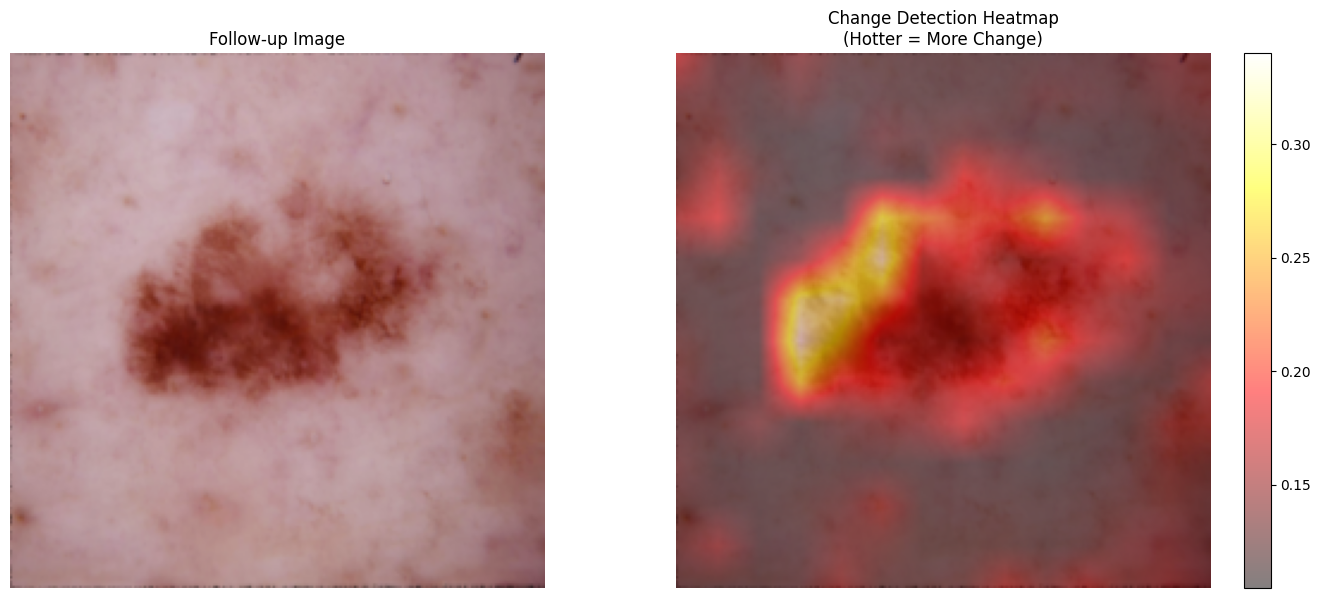

In [28]:
# Visualize change heatmaps for concerning cases
print("\nVisualizing change heatmaps for concerning cases...")
concerning_samples = [i for i in range(len(test_pair_dataset)) 
                      if test_pair_dataset[i]['binary_label'] == 1][:3]

for idx in concerning_samples:
    sample = test_pair_dataset[idx]
    visualize_change_heatmap(
        sample['baseline'],
        sample['followup'],
        model,
        device
    )


Visualizing feature evolution...


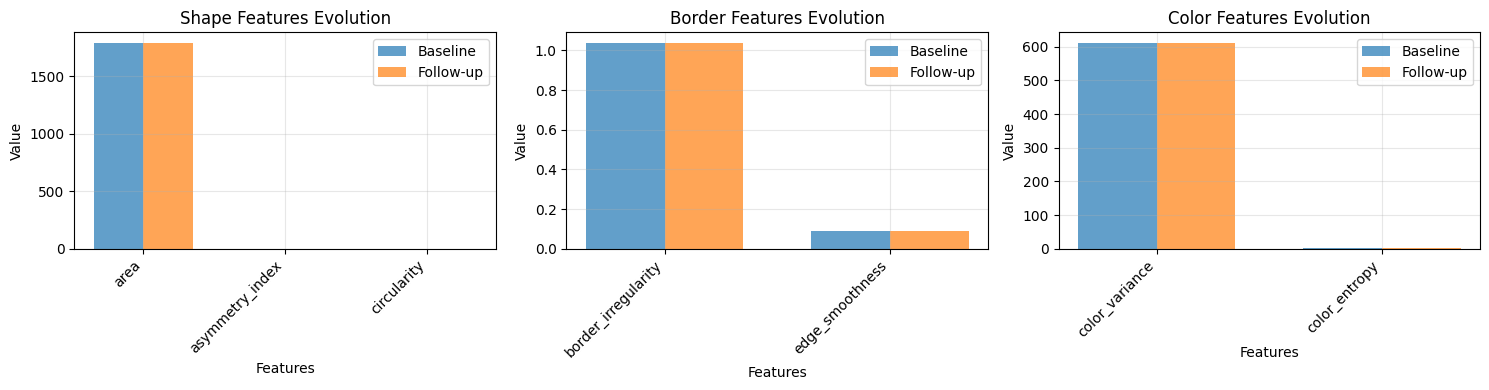

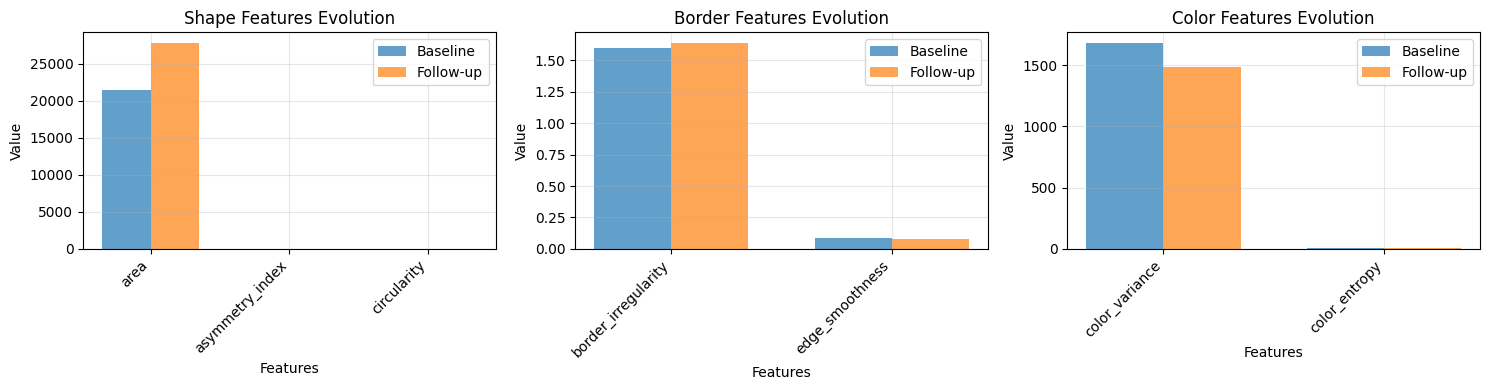

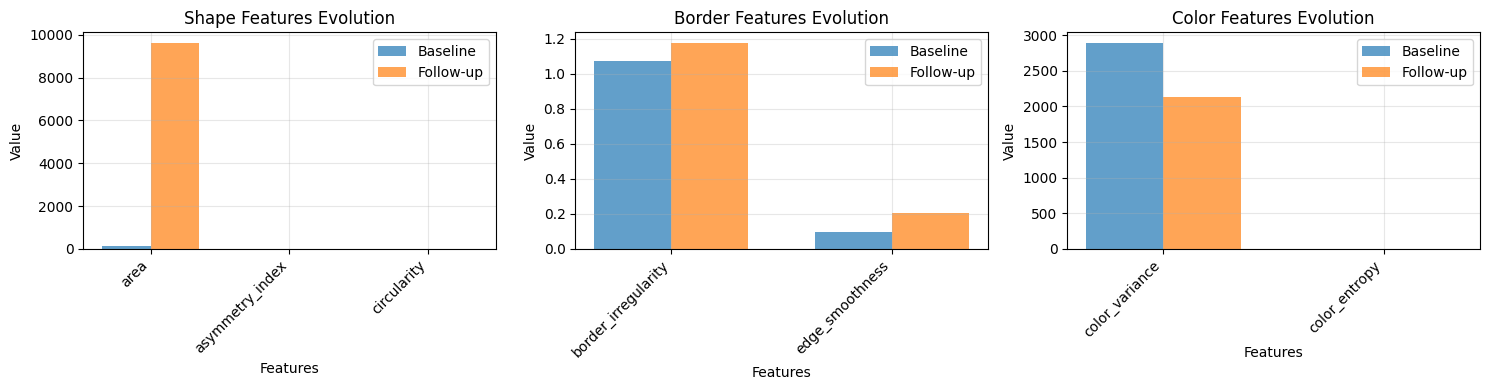

In [36]:
# Visualize feature evolution
print("\nVisualizing feature evolution...")
for idx in range(min(3, len(test_pair_dataset))):
    sample = test_pair_dataset[idx]
    
    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return tensor * std + mean
    
    baseline_img = Image.fromarray(
        (denormalize(sample['baseline']).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    )
    followup_img = Image.fromarray(
        (denormalize(sample['followup']).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    )
    
    plot_feature_evolution(sample['baseline'], sample['followup'], feature_extractor)

In [37]:
# Override visualize_change_heatmap to handle CLS token shape issues
import numpy as np
import scipy.ndimage

def visualize_change_heatmap(baseline_img, followup_img, model, device):
    """Create heatmap showing where changes are detected (CLS-safe)."""
    model.eval()
    baseline_tensor = baseline_img.unsqueeze(0).to(device)
    followup_tensor = followup_img.unsqueeze(0).to(device)

    with torch.no_grad():
        baseline_features = model.encoder.forward_features(baseline_tensor)
        followup_features = model.encoder.forward_features(followup_tensor)
        feature_diff = torch.abs(followup_features - baseline_features)
        patch_importance = feature_diff.mean(dim=-1).squeeze().cpu().numpy()

    # Drop CLS token if present (e.g., 197 = 1 CLS + 196 patches)
    if patch_importance.shape[0] > 1 and int(np.sqrt(patch_importance.shape[0] - 1)) ** 2 == (patch_importance.shape[0] - 1):
        patch_importance = patch_importance[1:]

    # Reshape to spatial grid
    spatial_size = int(np.sqrt(patch_importance.shape[0]))
    patch_importance = patch_importance.reshape(spatial_size, spatial_size)

    # Upsample to image size
    heatmap = scipy.ndimage.zoom(patch_importance, (224/spatial_size, 224/spatial_size), order=1)

    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        return tensor * std + mean

    followup_display = denormalize(followup_img).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(followup_display)
    axes[0].set_title('Follow-up Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(followup_display)
    heatmap_overlay = axes[1].imshow(heatmap, alpha=0.5, cmap='hot', interpolation='bilinear')
    axes[1].set_title('Change Detection Heatmap\n(Hotter = More Change)', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(heatmap_overlay, ax=axes[1], fraction=0.046)

    plt.tight_layout()
    plt.show()


## Section 7: Summary and Model Usage

### Key Features

1. **Temporal Change Detection**: Instead of binary melanoma classification, the model detects clinically concerning changes in lesions over time.

2. **Vision Transformer Architecture**: Uses ViT with temporal attention to compare baseline and follow-up images.

3. **Feature Tracking**: Tracks shape (area, asymmetry, circularity), border (irregularity, smoothness), and color (variance, entropy) features.

4. **Multi-level Output**: 
   - Multi-class: None, Minor, Moderate, Significant change
   - Binary: Concerning vs Non-concerning change

### Legal Safety

The model is designed to answer: **"Has this lesion changed in a clinically concerning way?"** rather than "Is this melanoma?" This approach is:
- Legally safer (monitoring tool, not diagnostic tool)
- More clinically useful (tracks progression over time)
- Compliant with medical device regulations

### Model Inference

To use the trained model for inference on new image pairs:

```python
# Load model
model.load_state_dict(torch.load('best_change_detection_model.pth'))
model.eval()

# Prepare images (baseline and followup)
baseline_tensor = transform(baseline_image).unsqueeze(0).to(device)
followup_tensor = transform(followup_image).unsqueeze(0).to(device)

# Get predictions
with torch.no_grad():
    multi_logits, binary_logits = model(baseline_tensor, followup_tensor)
    change_class = multi_logits.argmax(dim=1).item()
    concerning_prob = torch.sigmoid(binary_logits).item()

severity_names = ['None', 'Minor', 'Moderate', 'Significant']
print(f"Change severity: {severity_names[change_class]}")
print(f"Concerning change probability: {concerning_prob:.3f}")
```

### Important Disclaimer

**This is a monitoring tool, not a diagnostic tool.** Users should always consult with healthcare professionals for medical diagnosis and treatment decisions.

In [38]:
# Final model summary
print("=" * 60)
print("SKIN CANCER TEMPORAL CHANGE DETECTION SYSTEM")
print("=" * 60)
print(f"\nModel Architecture: Vision Transformer (ViT-Base)")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nDataset:")
print(f"  Training pairs: {len(train_pair_dataset)}")
print(f"  Validation pairs: {len(val_pair_dataset)}")
print(f"  Test pairs: {len(test_pair_dataset)}")
print(f"\nTest Performance:")
print(f"  Multi-class Accuracy: {test_metrics['acc_multi']:.4f}")
print(f"  Binary Accuracy: {test_metrics['acc_binary']:.4f}")
print(f"  ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"\nModel saved to: best_change_detection_model.pth")
print("\n" + "=" * 60)

SKIN CANCER TEMPORAL CHANGE DETECTION SYSTEM

Model Architecture: Vision Transformer (ViT-Base)
Total Parameters: 89,937,029

Dataset:
  Training pairs: 2800
  Validation pairs: 600
  Test pairs: 600

Test Performance:
  Multi-class Accuracy: 0.7650
  Binary Accuracy: 0.9150
  ROC-AUC: 0.9533

Model saved to: best_change_detection_model.pth



## Section 8: Inference on Your Images (Change Detection)

Provide a baseline and follow-up image path to get change severity and a "concerning change" probability. This flags concerning evolution; it does **not** diagnose melanoma.

In [41]:
# Inference helper for user-provided images
from pathlib import Path

def load_image_for_inference(img_path: str, transform=val_transform):
    img_path = Path(img_path)
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = Image.open(img_path).convert('RGB')
    return transform(img)

def run_change_detection_inference(baseline_path: str, followup_path: str = None):
    """Run change detection on user-provided images.
    If followup_path is None, the same image is used (not meaningful for change detection).
    """
    model.eval()
    if followup_path is None:
        followup_path = baseline_path
        print("Warning: No follow-up provided; using the same image. Change detection will likely show 'None' change.")
    
    baseline_tensor = load_image_for_inference(baseline_path).unsqueeze(0).to(device)
    followup_tensor = load_image_for_inference(followup_path).unsqueeze(0).to(device)
    
    with torch.no_grad():
        multi_logits, binary_logits = model(baseline_tensor, followup_tensor)
        severity_names = ['None', 'Minor', 'Moderate', 'Significant']
        change_class = multi_logits.argmax(dim=1).item()
        concerning_prob = torch.sigmoid(binary_logits).item()
    
    print("Inference results:")
    print(f"  Baseline image: {baseline_path}")
    print(f"  Follow-up image: {followup_path}")
    print(f"  Change severity: {severity_names[change_class]}")
    print(f"  Concerning change probability: {concerning_prob:.3f}")
    print("Note: This detects concerning change; it does not diagnose melanoma.")
    return severity_names[change_class], concerning_prob

# Example usage (replace paths with your images):
# severity, prob = run_change_detection_inference('path/to/baseline.jpg', 'path/to/followup.jpg')
# If you only have one image, pass None for followup (not meaningful for change but will run):
# severity, prob = run_change_detection_inference('path/to/image.jpg', None)